# ***Predictive Analysis-I*** 

<span style="color: red;">1. Bivariate model ---> Simple logistic regression</span>

1. Bivariate model ---> Simple logistic regression
2. Multivariate model ---> To show transformation and encoding
3. Full model ----> Pipeline concept, GridSearchCV, SMOTE algorithms

# I Bivariate Model

<h2 style="color:green" align="center">Objective: To predict if a worker would be involved in unsafe act based on his/her age.</h2>

In [82]:
#Import essential libraries
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline

In [87]:
# Import data
# df = pd.read_csv("unsafe acts.csv") 
df = pd.read_csv("unsafe_act.csv") 
df.head()

,age,unsafe_act
0,22,0
1,25,0
2,47,1
3,52,0
4,46,1



### Exploratory data analysis (EDA)

In [88]:
# To check the variable types
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   age         27 non-null     int64
 1   unsafe_act  27 non-null     int64
dtypes: int64(2)
memory usage: 564.0 bytes


In [89]:
#Missing data check
df.isna().sum()

age           0
unsafe_act    0
dtype: int64

In [91]:
df.describe().round()

,age,unsafe_act
count,27.0,27.0
mean,40.0,1.0
std,16.0,1.0
min,18.0,0.0
25%,25.0,0.0
50%,45.0,1.0
75%,54.0,1.0
max,62.0,1.0


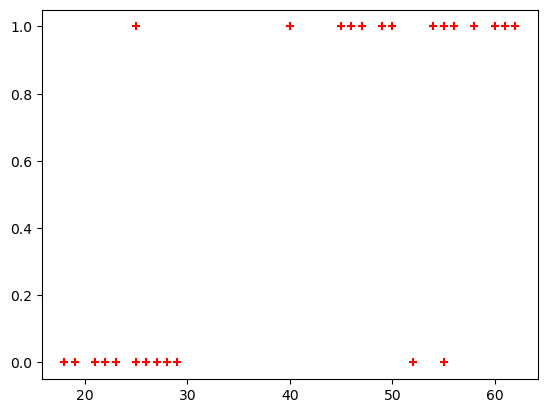

In [94]:
# Scatter plot
plt.scatter(df.age,df.unsafe_act,marker='+',color='red')

### Model building

<p style='color:purple'><b>The approach we are going to use here is to split available data in two sets</b></p>
    <ol>
        <b>
        <li>Training: We will train our model on this dataset</li>
        <li>Testing: We will use this subset to make actual predictions using trained model</li>
        </b>
     </ol>
<p style='color:green'><b>The reason we don't use same training set for testing is because our model has seen those samples before, using same samples for making predictions might give us wrong impression about accuracy of our model. It is like you ask same questions in exam paper as you tought the students in the class.
</b></p>

In [95]:
# Model building
from sklearn.model_selection import train_test_split

In [97]:
X_train, X_test, y_train, y_test = train_test_split(df[['age']],df.unsafe_act,train_size=0.8)

In [98]:
# Just to check how many rows are being selected for train and test
X_train.count()

age    21
dtype: int64

In [99]:
X_test.count()

age    6
dtype: int64

In [100]:
# Fit logsitc regression model on train data using sklearn

#Using sklearn 
from sklearn.linear_model import LogisticRegression

# Fitting model on the training data
log_model = LogisticRegression() #saving the model in the object "log_model"
log_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [101]:
#Predict using the test data

y_predicted = log_model.predict(X_test)
y_predicted

array([0, 1, 1, 1, 1, 1])

In [104]:
X_test

,age
10,18
8,62
15,55
22,40
2,47
6,55


In [123]:
# To know the predicted probabilities for y_test/y prboabilites
log_model.predict_proba(X_test)

# OR

# y_prob  = log_model.predict_proba(X_test)
# y_prob

array([[0.96138486, 0.03861514],
       [0.02340482, 0.97659518],
       [0.06747701, 0.93252299],
       [0.43580626, 0.56419374],
       [0.20371696, 0.79628304],
       [0.06747701, 0.93252299]])

In [120]:
# To estimate the model score, i.e. accuracy

log_model.score(X_test,y_test)


0.8333333333333334

***model.coef_ indicates value of m in y=m*x + b equation**

In [107]:
log_model.coef_

array([[0.15786046]])

In [108]:
log_model.intercept_

array([-6.05621863])

**Let's define sigmoid function and do the math with hand**

In [109]:
import math
def sigmoid(x):
  return 1 / (1 + math.exp(-x))

In [110]:
def prediction_function(age):
    z = 2.15 * age - 76.32 # 0.04150133 ~ 0.042 and -1.52726963 ~ -1.53
    y = sigmoid(z)
    return y

In [113]:
age = 19
prediction_function(age)

3.9407122768791726e-16

the value is less than 0.5, which means a worker aged 35 will not be involved in an unsafe act.

In [114]:
age = 36
prediction_function(age)

0.7464939833376619

0.7465 is greater than 0.5, which means a worker aged 36 will be involved in an unsafe act.

In [125]:
X = df[["age"]]
y = df["unsafe_act"]

In [128]:
# To save results in a csv format
# Predict probabilities (class = 1)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Convert X_test to DataFrame if needed
X_test_df = pd.DataFrame(X_test, columns=X.columns)


# Create results table
results_table = X_test_df.copy()
results_table["y_test"] = y_test.values
results_table["predicted_probability"] = y_prob
results_table["y_pred"] = log_model.predict(X_test)


# Display first 10 rows
results_table.head()

# Save as csv
results_table.to_csv("bivariate_results.csv")


,age,y_test,predicted_probability,y_pred
10,18,0,0.038615,0
8,62,1,0.976595,1
15,55,1,0.932523,1
22,40,1,0.564194,1
2,47,1,0.796283,1


In [131]:
# To view full table
results_table

,age,y_test,predicted_probability,y_pred
10,18,0,0.038615,0
8,62,1,0.976595,1
15,55,1,0.932523,1
22,40,1,0.564194,1
2,47,1,0.796283,1
6,55,0,0.932523,1


In [132]:
# Save as csv
results_table.to_csv("bivariate_results.csv")

# The End